In [8]:
# Data Loading and initial Data Inspection
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.ensemble import RandomForestClassifier

In [9]:
import sys
print(sys.executable)

/Users/benjyvail/Documents/COMP0050/venv/bin/python


In [10]:
# Inspect the structure of the dataset and generate summary statistics for numerical variables
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()
df.info()
df.describe()
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

/var/folders/l0/52jm2csn11zg85_g5ktcdh3h0000gn/T/ipykernel_45189/4281889969.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette='viridis', ax=ax[1])


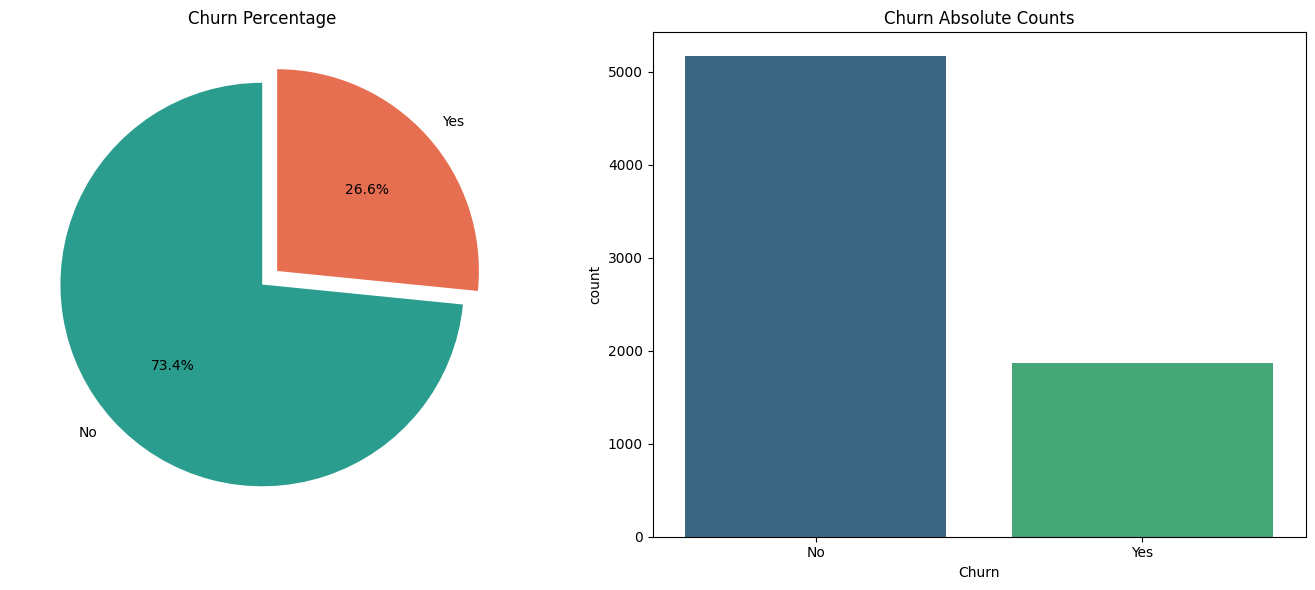

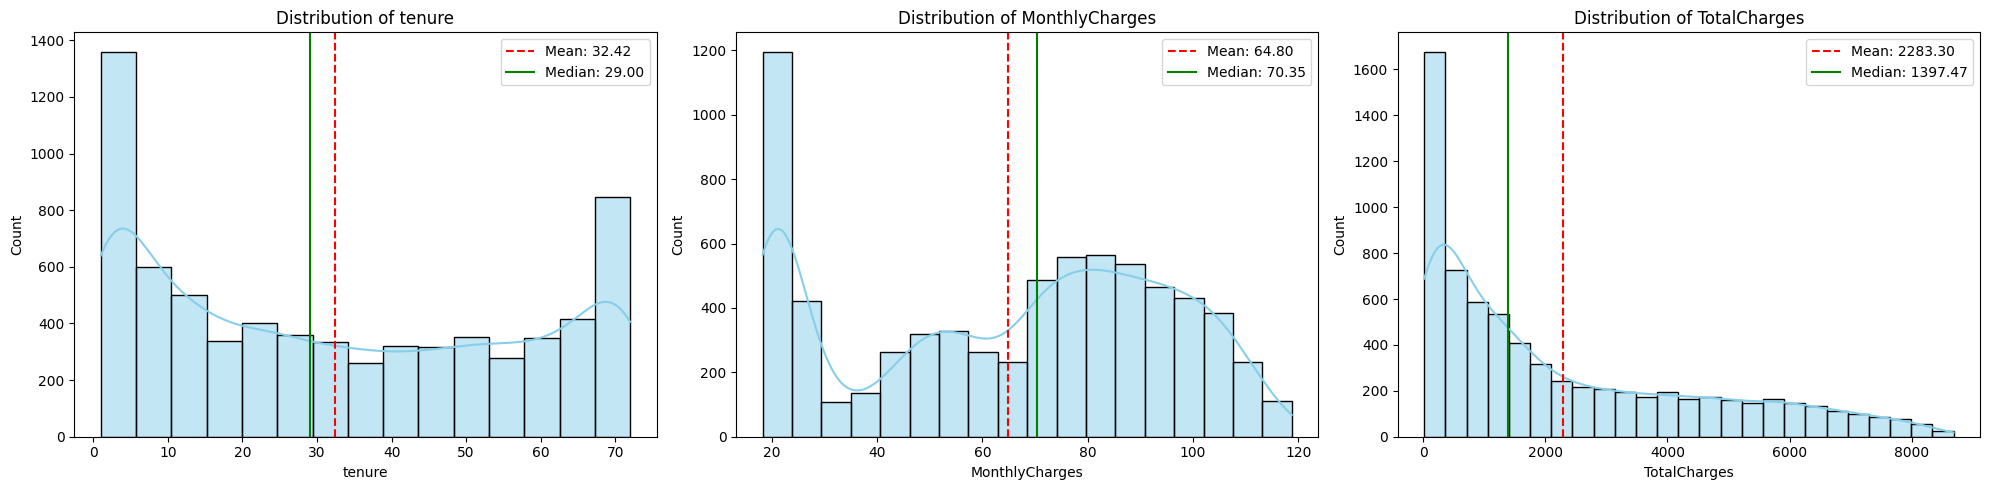

/var/folders/l0/52jm2csn11zg85_g5ktcdh3h0000gn/T/ipykernel_45189/4281889969.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y=col, ax=axes[i], palette='Set2')
/var/folders/l0/52jm2csn11zg85_g5ktcdh3h0000gn/T/ipykernel_45189/4281889969.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y=col, ax=axes[i], palette='Set2')
/var/folders/l0/52jm2csn11zg85_g5ktcdh3h0000gn/T/ipykernel_45189/4281889969.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y=col, ax=axes[i], palette='Se

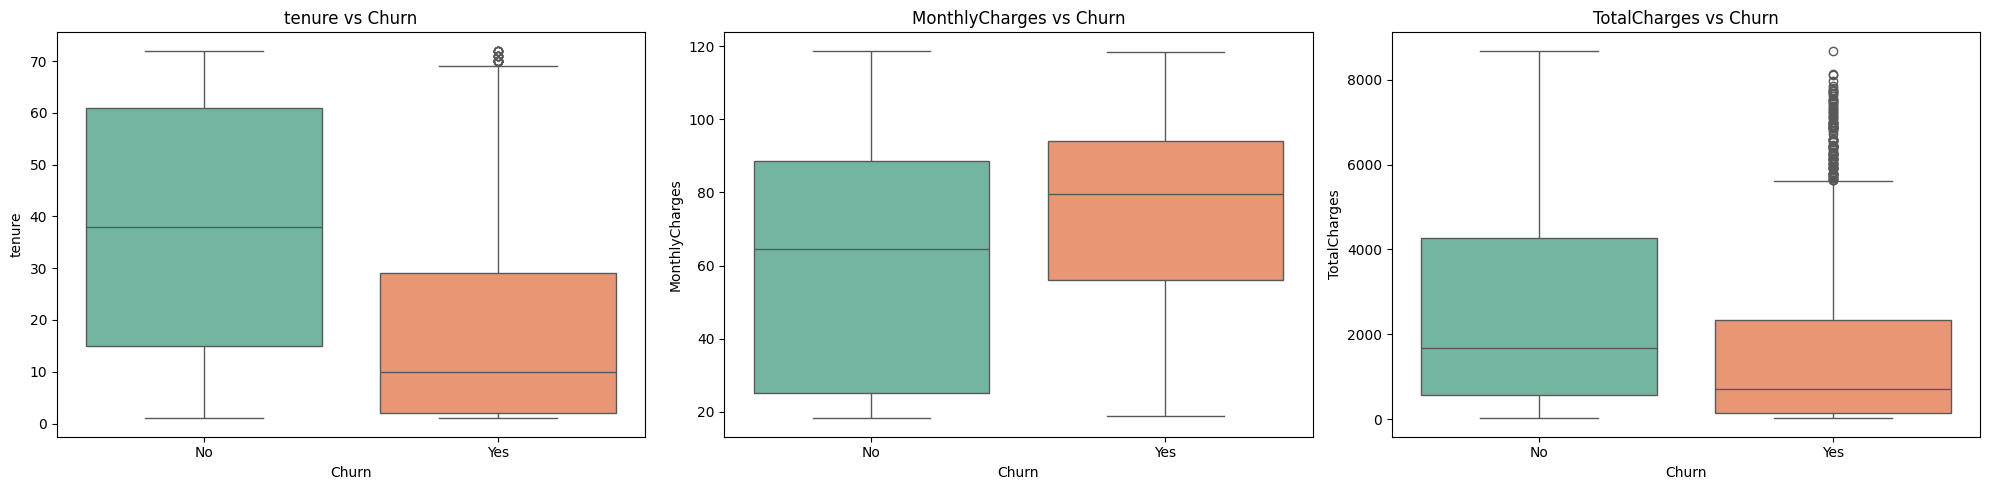

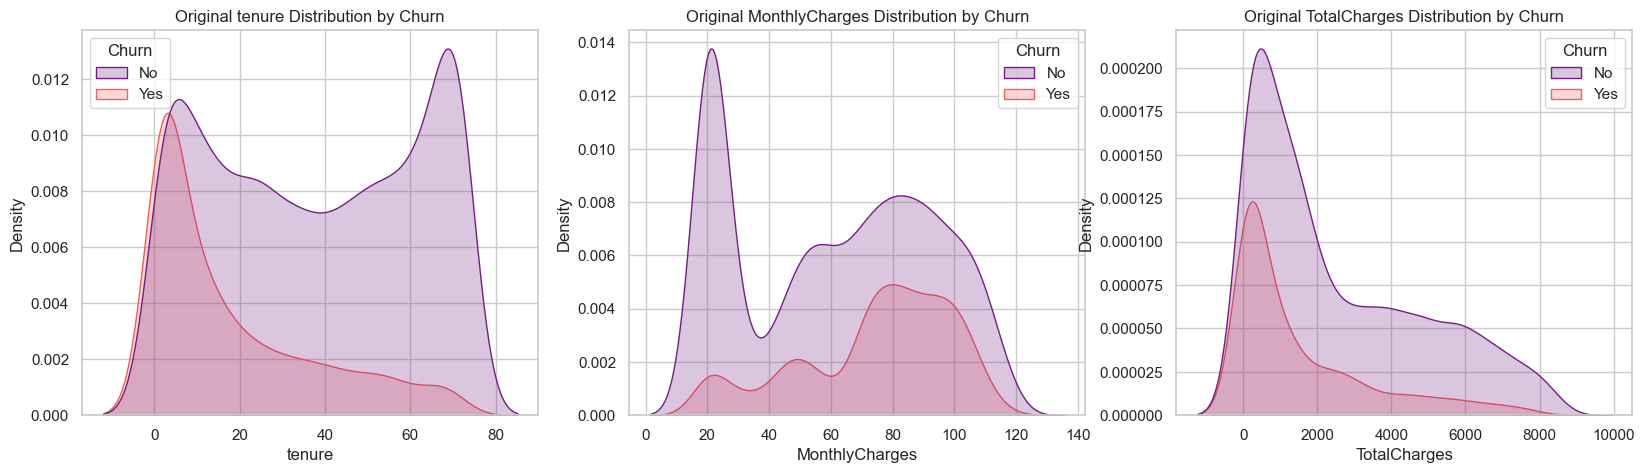

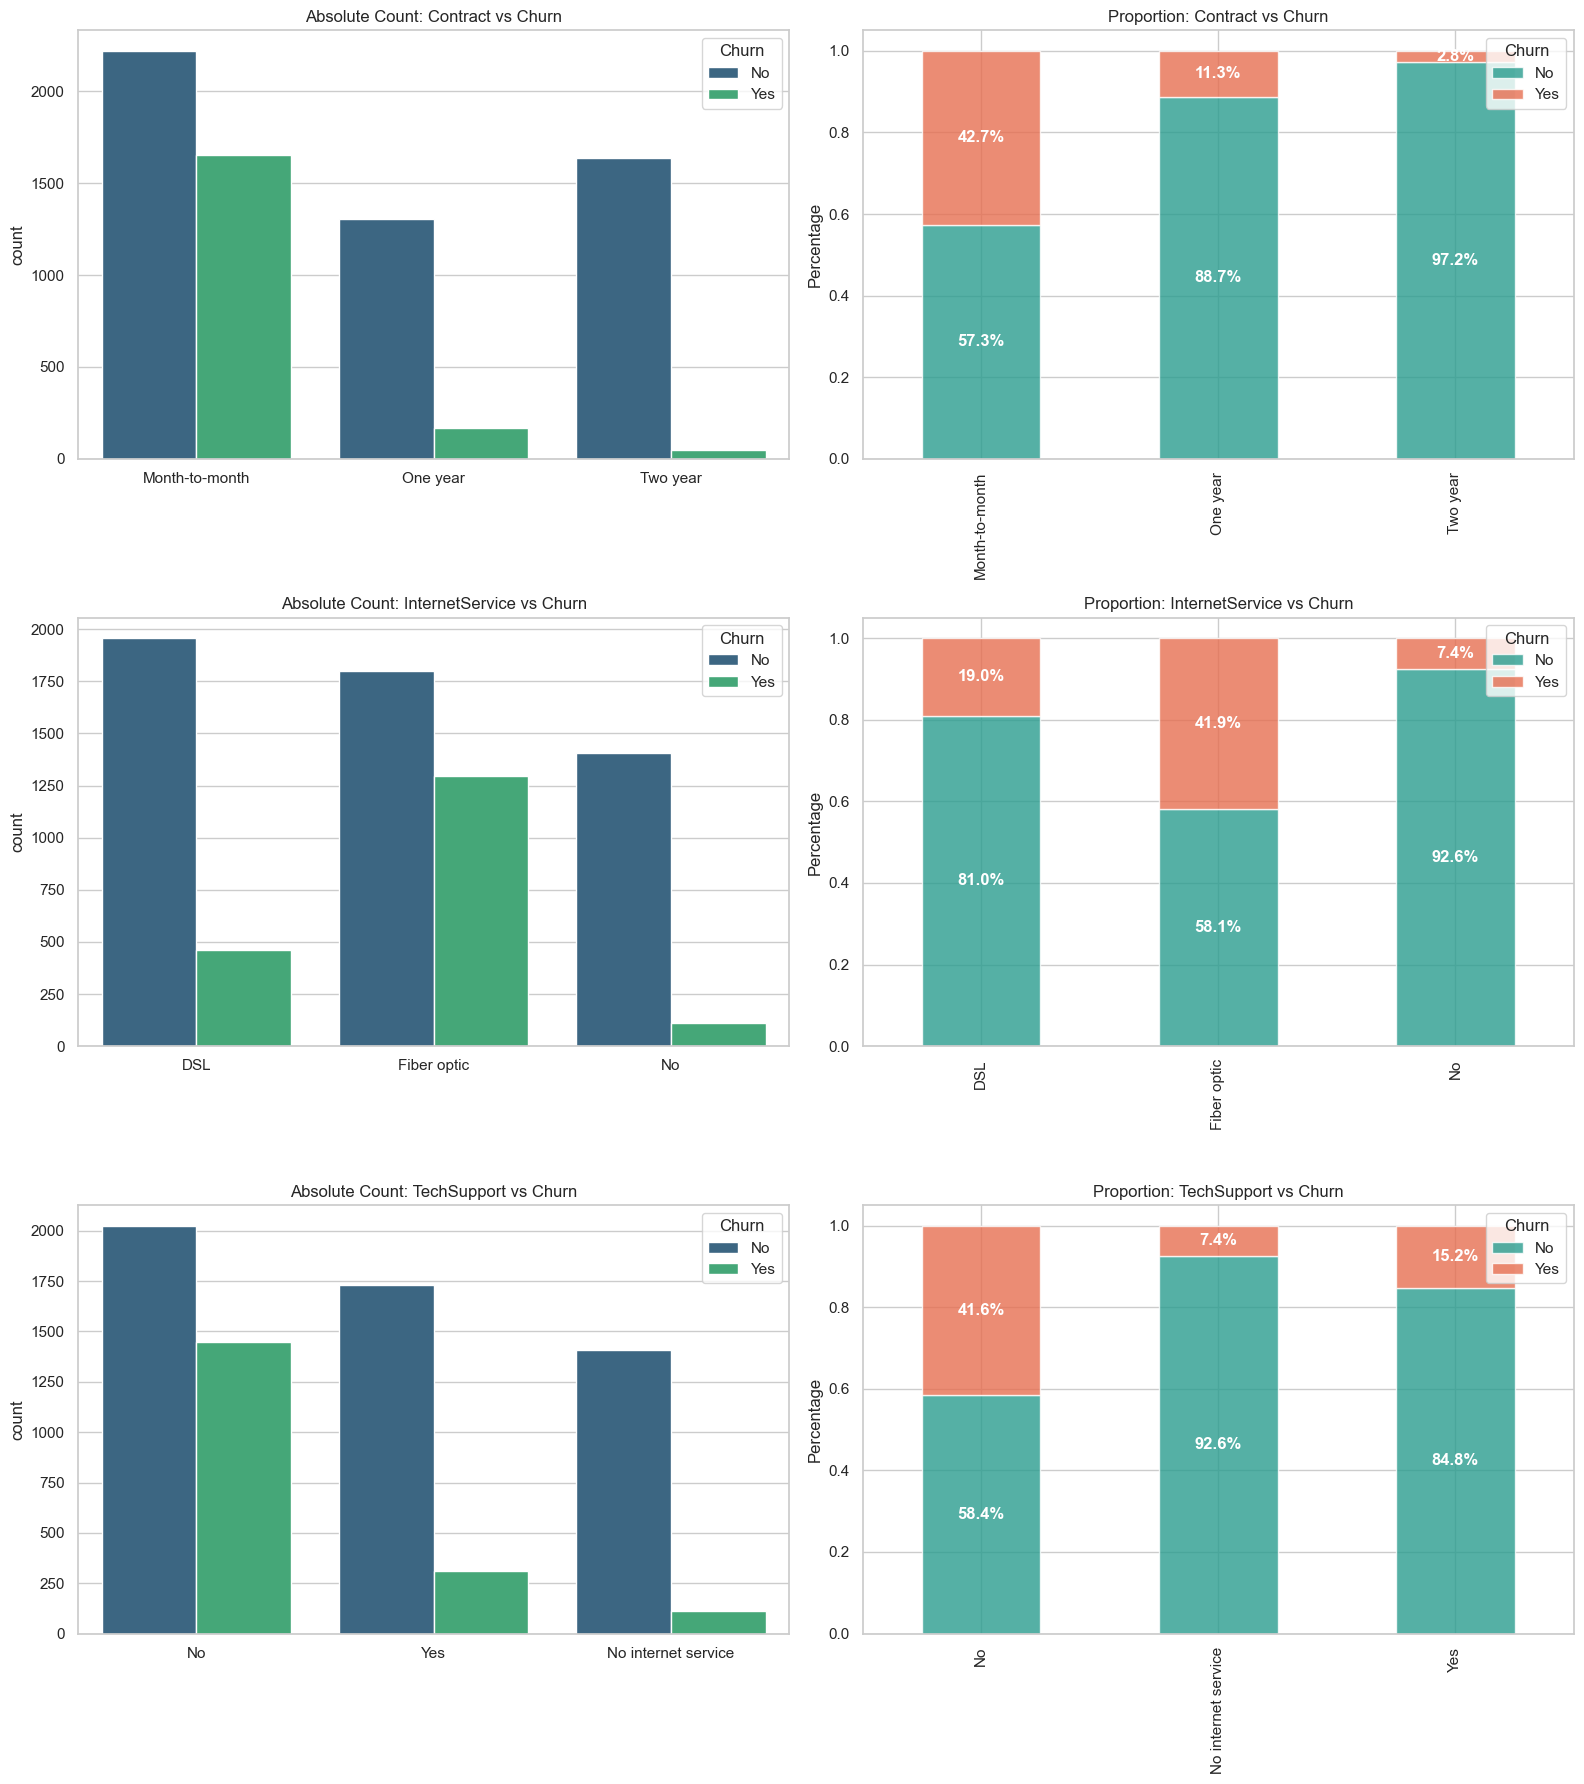

/var/folders/l0/52jm2csn11zg85_g5ktcdh3h0000gn/T/ipykernel_45189/4281889969.py:97: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=service_churn_rate, x='InternetService', y='Churn', palette='magma')
/var/folders/l0/52jm2csn11zg85_g5ktcdh3h0000gn/T/ipykernel_45189/4281889969.py:103: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='InternetService', y='MonthlyCharges', palette='magma')


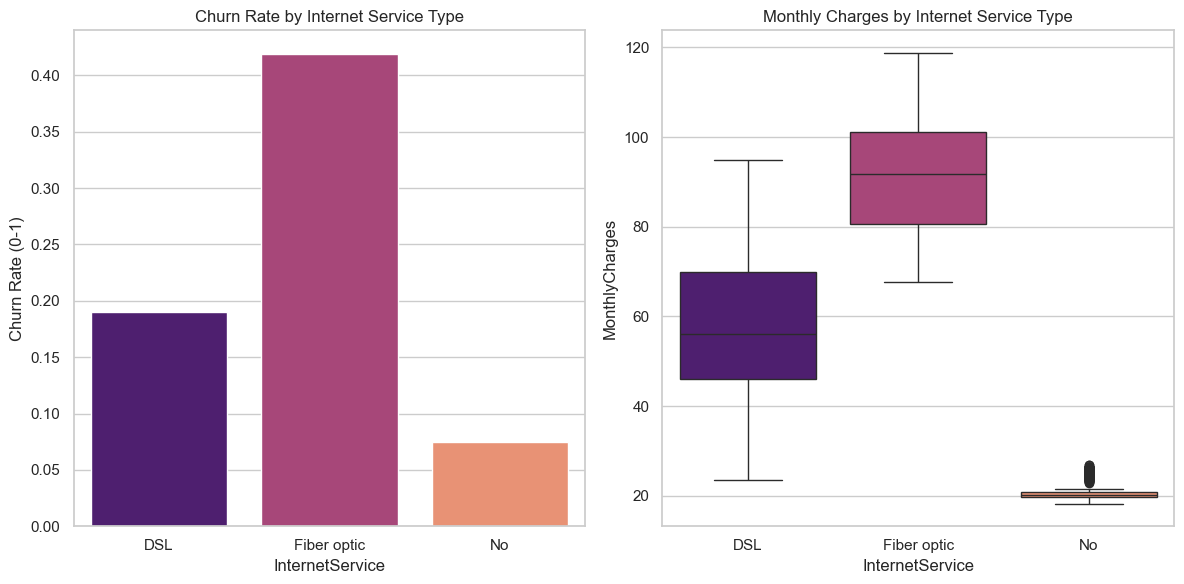

In [11]:
# Churn Distribution
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# pie chart: focus on proportion
churn_counts = df['Churn'].value_counts()
ax[0].pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%', 
        startangle=90, colors=['#2a9d8f', '#e76f51'], explode=[0, 0.1])
ax[0].set_title('Churn Percentage')

# counting chart: focus on absolute numbers
sns.countplot(data=df, x='Churn', palette='viridis', ax=ax[1])
ax[1].set_title('Churn Absolute Counts')
plt.tight_layout()
plt.show()

# Numerical Feature Distribution 
# Define numerical features
num_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for i, col in enumerate(num_features):
    # Use histplot in combination with KDE curves to observe the distribution pattern
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribution of {col}')
    
    # Basic statistics
    mean_val = df[col].mean()
    median_val = df[col].median()
    axes[i].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
    axes[i].axvline(median_val, color='green', linestyle='-', label=f'Median: {median_val:.2f}')
    axes[i].legend()

plt.tight_layout()
plt.show()

# Numerical features vs Churn
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for i, col in enumerate(num_features):
    sns.boxplot(data=df, x='Churn', y=col, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} vs Churn')
plt.tight_layout()
plt.show()
sns.set_theme(style="whitegrid")

# Create a drawing canvas layout
plt.rcParams['figure.figsize'] = (12, 8)
num_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for i, col in enumerate(num_features):
    sns.kdeplot(data=df, x=col, hue='Churn', fill=True, ax=axes[i], palette='magma')
    axes[i].set_title(f'Original {col} Distribution by Churn')
    
plt.show()

# Categorical Features
sns.set_theme(style="whitegrid")
features = ['Contract', 'InternetService', 'TechSupport']
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(16, 18))
plt.subplots_adjust(hspace=0.4)

for i, col in enumerate(features):
    # left pictue: Countplot
    sns.countplot(data=df, x=col, hue='Churn', ax=axes[i, 0], palette='viridis')
    axes[i, 0].set_title(f'Absolute Count: {col} vs Churn')
    axes[i, 0].set_xlabel('')
    
    # right picture：Stacked Bar Chart
    # Calculate the percentage of Churn in each category
    prop_df = (df.groupby([col, 'Churn']).size() / df.groupby(col).size()).reset_index(name='percent')
    
    # Use pivot to rearrange the data in order to draw a stacked chart
    pivot_df = prop_df.pivot(index=col, columns='Churn', values='percent')  
    pivot_df.plot(kind='bar', stacked=True, ax=axes[i, 1], color=['#2a9d8f', '#e76f51'], alpha=0.8)
    axes[i, 1].set_title(f'Proportion: {col} vs Churn')
    axes[i, 1].set_ylabel('Percentage')
    axes[i, 1].set_xlabel('')
    axes[i, 1].legend(title='Churn', loc='upper right')
    
    for p in axes[i, 1].patches:
        width, height = p.get_width(), p.get_height()
        x, y = p.get_xy() 
        if height > 0: 
            axes[i, 1].annotate(f'{height:.1%}', (x + width/2, y + height/2), ha='center', va='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

# Internet Service Breakdown
plt.figure(figsize=(12, 6))

# 1. Internet service churn rate breakdown
plt.subplot(1, 2, 1)

# Calculate the proportion of 'Yes' churn cases in each service type
service_churn_rate = df.groupby('InternetService')['Churn'].apply(lambda x: (x == 'Yes').mean()).reset_index()
sns.barplot(data=service_churn_rate, x='InternetService', y='Churn', palette='magma')
plt.title('Churn Rate by Internet Service Type')
plt.ylabel('Churn Rate (0-1)')

# 2. Monthly fee distribution for different network services
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='InternetService', y='MonthlyCharges', palette='magma')
plt.title('Monthly Charges by Internet Service Type')
plt.tight_layout()
plt.show()

In [12]:
# Removing Irrelevant Variables
df.drop("customerID", axis=1, inplace=True)

# Handling Missing Values
df["TotalCharges"].head()
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df.dropna(inplace=True)
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [13]:
cleaned_df = df.copy()
# Target Variable Transformation
cleaned_df["Churn"] = cleaned_df["Churn"].map({"Yes": 1, "No": 0})


# Encoding Categorical Variables
# Use One-Hot encoding to handle all categorical features
cleaned_df = pd.get_dummies(cleaned_df, drop_first=True)

# Convert the generated True/False values to 1/0 to prevent errors in subsequent plotting or calculations
bool_cols = cleaned_df.select_dtypes(include='bool').columns
cleaned_df[bool_cols] = cleaned_df[bool_cols].astype(int)

# Feature Scaling
scaler = StandardScaler()
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
cleaned_df[num_cols] = scaler.fit_transform(cleaned_df[num_cols])
print("--- Cleaned Dataframe Info ---")
cleaned_df.info()
cleaned_df.to_csv("telco_churn_cleaned.csv", index=False)

--- Cleaned Dataframe Info ---
<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7032 non-null   int64  
 1   tenure                                 7032 non-null   float64
 2   MonthlyCharges                         7032 non-null   float64
 3   TotalCharges                           7032 non-null   float64
 4   Churn                                  7032 non-null   int64  
 5   gender_Male                            7032 non-null   int64  
 6   Partner_Yes                            7032 non-null   int64  
 7   Dependents_Yes                         7032 non-null   int64  
 8   PhoneService_Yes                       7032 non-null   int64  
 9   MultipleLines_No phone service         7032 non-null   int64  
 10  MultipleLines_Yes                      7032 non-null   in

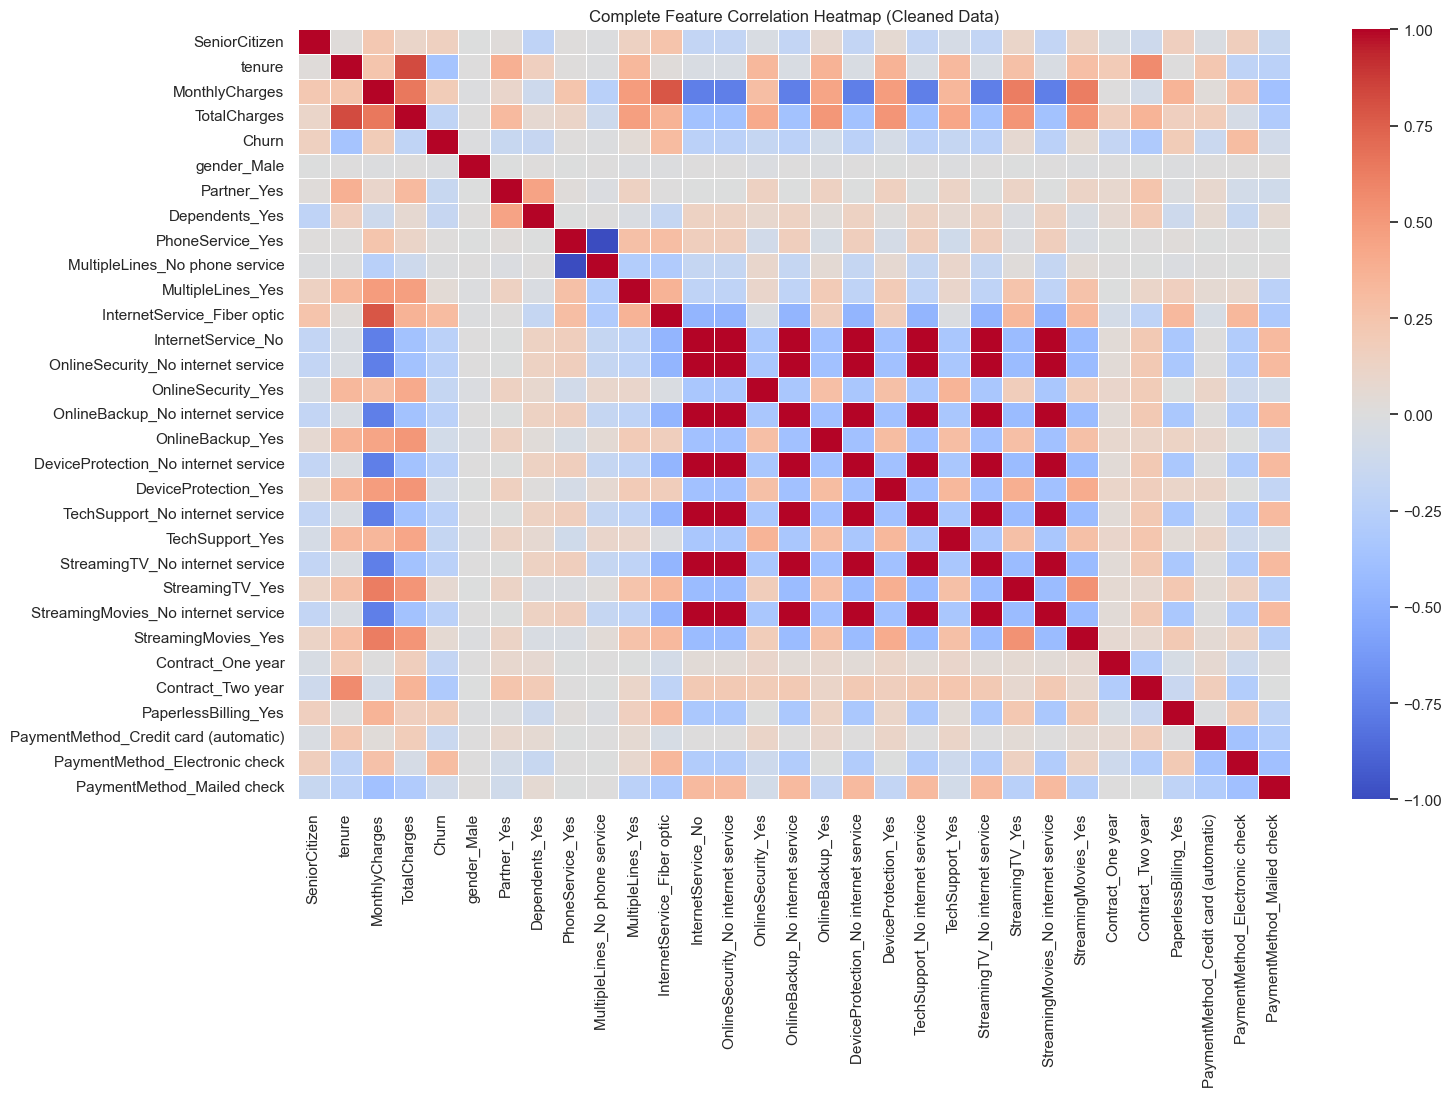

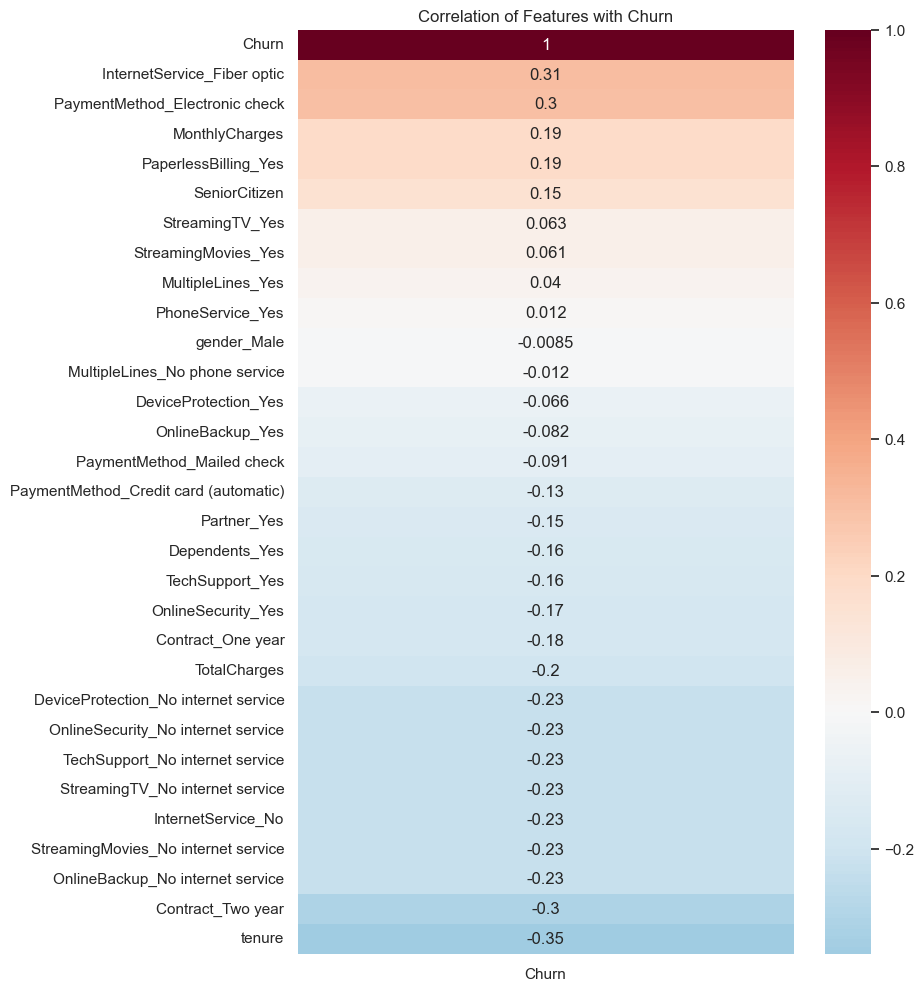

In [17]:
# Correlation heatmap
plt.figure(figsize=(16, 10))

# 1. Calculate correlation matrix
corr_matrix = cleaned_df.corr()
churn_corr = corr_matrix[['Churn']].sort_values(by='Churn', ascending=False)

# 2. Plot the heatmap
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Complete Feature Correlation Heatmap (Cleaned Data)')
plt.show()

# 3. Identify the top features that are most relevant to Churn
plt.figure(figsize=(8, 12))
sns.heatmap(churn_corr, annot=True, cmap='RdBu_r', center=0)
plt.title('Correlation of Features with Churn')
plt.show()

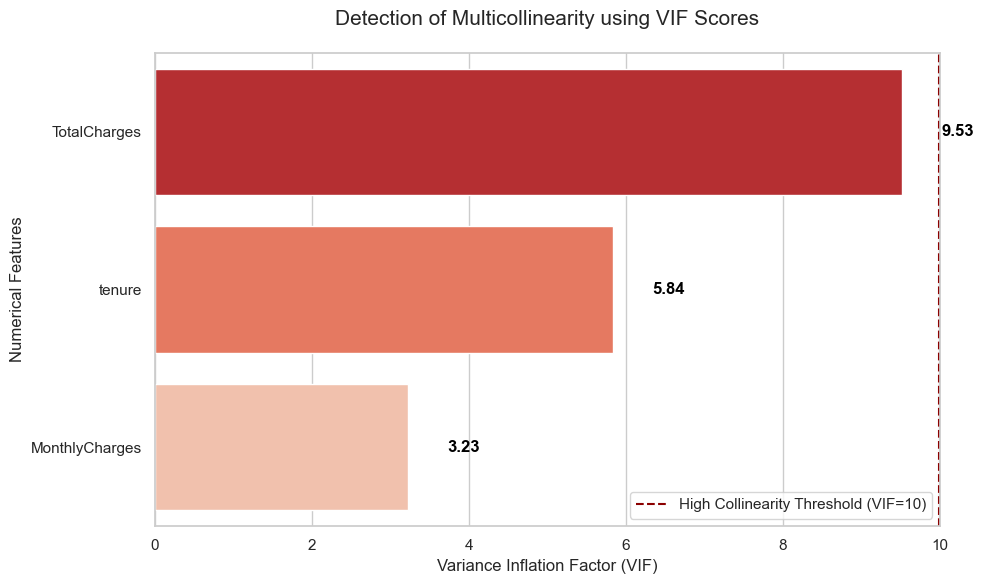

VIF ranking：
          feature       VIF
2    TotalCharges  9.526697
0          tenure  5.844646
1  MonthlyCharges  3.225293


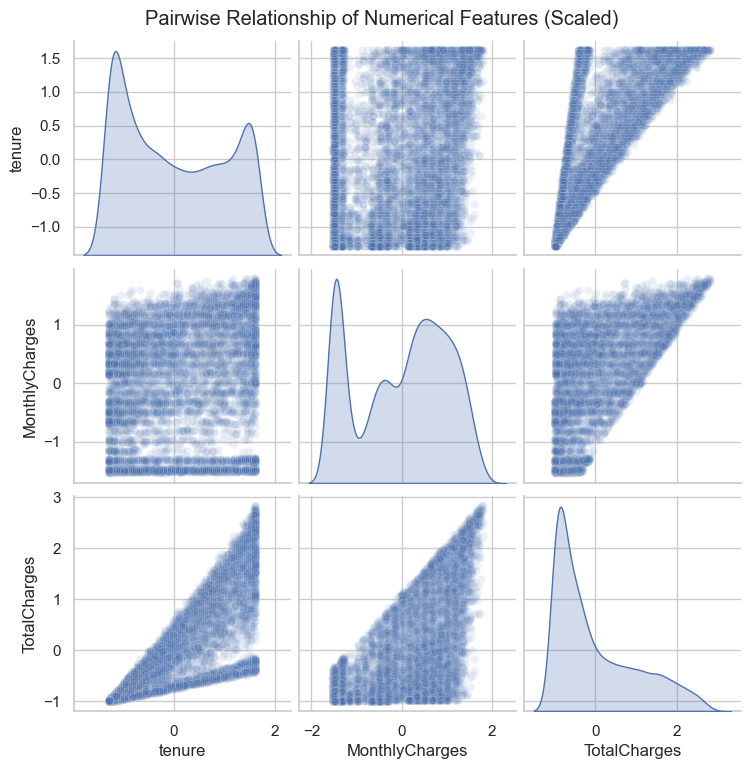

In [18]:
# Multicollinearity Check
# Use VIF to check：

# 1. Select numerical features
vif_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
vif_data = cleaned_df[vif_cols]

# 2. Calculate VIF
vif_df = pd.DataFrame()
vif_df["feature"] = vif_data.columns
vif_df["VIF"] = [variance_inflation_factor(vif_data.values, i) for i in range(len(vif_data.columns))]

# 3. Sort the VIF results in descending order
vif_df_sorted = vif_df.sort_values(by="VIF", ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x="VIF", y="feature", data=vif_df_sorted, palette="Reds_r")

# 4. Add threshold reference line 
plt.axvline(x=10, color='darkred', linestyle='--', label='High Collinearity Threshold (VIF=10)')

# 5. Chart decoration
plt.title('Detection of Multicollinearity using VIF Scores', fontsize=15, pad=20)
plt.xlabel('Variance Inflation Factor (VIF)', fontsize=12)
plt.ylabel('Numerical Features', fontsize=12)
plt.legend(loc='lower right')

for i, v in enumerate(vif_df_sorted['VIF']):
    plt.text(v + 0.5, i, f'{v:.2f}', color='black', va='center', fontweight='bold')

plt.tight_layout()
plt.show()
print("VIF ranking：")
print(vif_df_sorted)

# Pairplot
# 1. Select numerical features for inspection
vif_data = cleaned_df[['tenure', 'MonthlyCharges', 'TotalCharges']]

# 2. Calculate the VIF for each feature
vif_df = pd.DataFrame()
vif_df["feature"] = vif_data.columns
vif_df["VIF"] = [variance_inflation_factor(vif_data.values, i) for i in range(len(vif_data.columns))]

# 3. Visualization of collinearity (scatter matrix)
sns.pairplot(vif_data, diag_kind='kde', plot_kws={'alpha': 0.1})
plt.suptitle('Pairwise Relationship of Numerical Features (Scaled)', y=1.02)
plt.show()

Top 10 Churn Drivers:
tenure                                  0.801469
TotalCharges                            0.451577
MonthlyCharges                          0.436577
InternetService_Fiber optic             0.345513
PaymentMethod_Electronic check          0.322404
Contract_Two year                       0.291382
PaperlessBilling_Yes                    0.212941
OnlineSecurity_No internet service      0.212056
TechSupport_No internet service         0.212056
DeviceProtection_No internet service    0.212056
Name: difference, dtype: float64


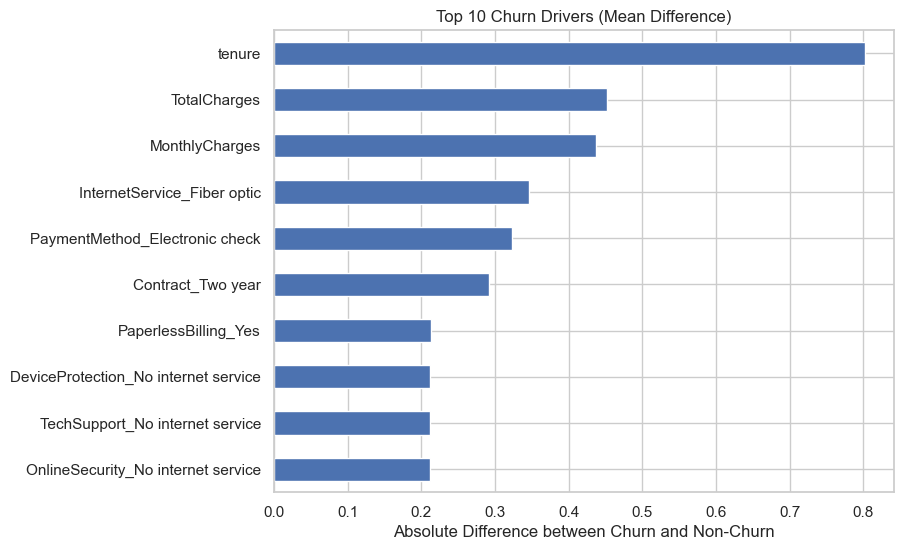

In [19]:
# Churn Drivers
# This method identifies churn drivers by comparing the mean values of each feature
# between churned and non-churned customers. The difference indicates how strongly
# a variable changes between the two groups.
# 1. Calculate the mean value by grouping according to "churn"
churn_mean = cleaned_df.groupby("Churn").mean().T

# 2. Calculate the difference
churn_mean["difference"] = churn_mean[1] - churn_mean[0]

# 3. Sort by the degree of influence
churn_drivers = churn_mean["difference"].abs().sort_values(ascending=False)

# 4. Select the 10 most important variables
top_churn_drivers = churn_drivers.head(10)
print("Top 10 Churn Drivers:")
print(top_churn_drivers)
top_churn_drivers.sort_values().plot(kind="barh", figsize=(8,6))
plt.title("Top 10 Churn Drivers (Mean Difference)")
plt.xlabel("Absolute Difference between Churn and Non-Churn")
plt.show()

Top 10 churn drivers:
TotalCharges                      0.196409
tenure                            0.173480
MonthlyCharges                    0.170253
InternetService_Fiber optic       0.037470
PaymentMethod_Electronic check    0.037387
Contract_Two year                 0.031570
gender_Male                       0.028105
OnlineSecurity_Yes                0.025491
PaperlessBilling_Yes              0.025157
Partner_Yes                       0.023409
dtype: float64


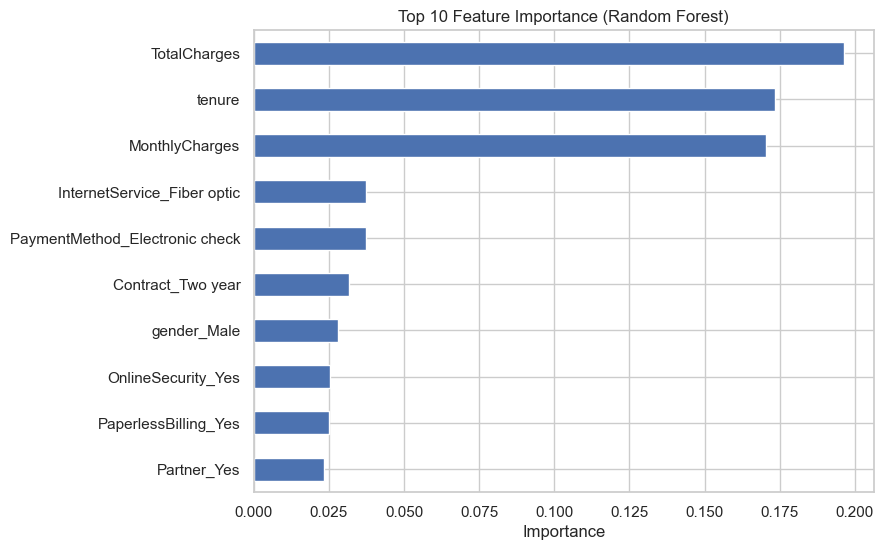

In [20]:
# Top feature ranking- Random Forest
# This method ranks features based on their statistical relationship with churn
# (e.g., correlation or model-based importance). It measures the strength of
# association between each feature and the churn variable.

# 1. Separate the independent variables (X) and the target variable (y)
X = cleaned_df.drop("Churn", axis=1)
y = cleaned_df["Churn"]

# 2. Build the Random Forest classification model
rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42
)
rf.fit(X, y)

# 3. Get feature importance
importances = rf.feature_importances_
feature_importance = pd.Series(
    importances,
    index=X.columns
)

# 4. Select top 10 important features
top_10 = feature_importance.sort_values(ascending=False).head(10)
print("Top 10 churn drivers:")
print(top_10)
top_10.sort_values().plot(
    kind="barh",
    figsize=(8,6)
)

plt.title("Top 10 Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.show()

Churn                                   1.000000
tenure                                  0.354049
InternetService_Fiber optic             0.307463
Contract_Two year                       0.301552
PaymentMethod_Electronic check          0.301455
OnlineBackup_No internet service        0.227578
DeviceProtection_No internet service    0.227578
TechSupport_No internet service         0.227578
StreamingMovies_No internet service     0.227578
InternetService_No                      0.227578
Name: Churn, dtype: float64


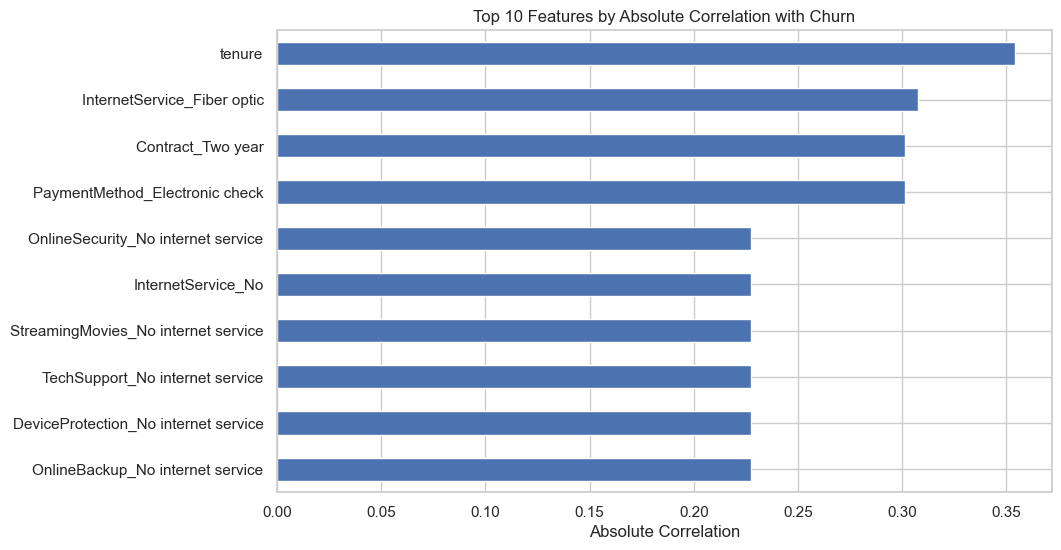

In [21]:
# Top feature ranking-correlation ranking
# Calculate correlation with churn and rank features by absolute correlation
feature_ranking_corr = cleaned_df.corr()["Churn"].abs().sort_values(ascending=False)
print(feature_ranking_corr.head(10))
top_corr_features = feature_ranking_corr.drop("Churn").head(10)

plt.figure(figsize=(10, 6))
top_corr_features.sort_values().plot(kind="barh")
plt.title("Top 10 Features by Absolute Correlation with Churn")
plt.xlabel("Absolute Correlation")
plt.show()

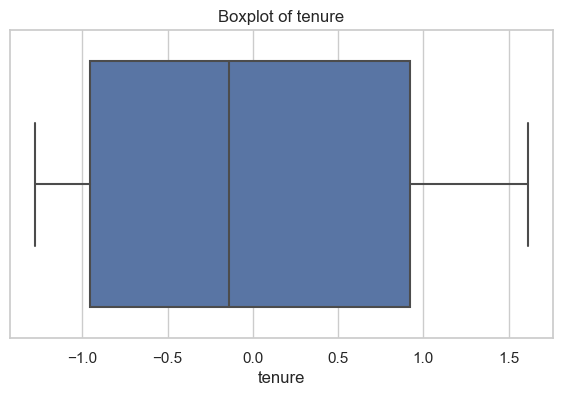

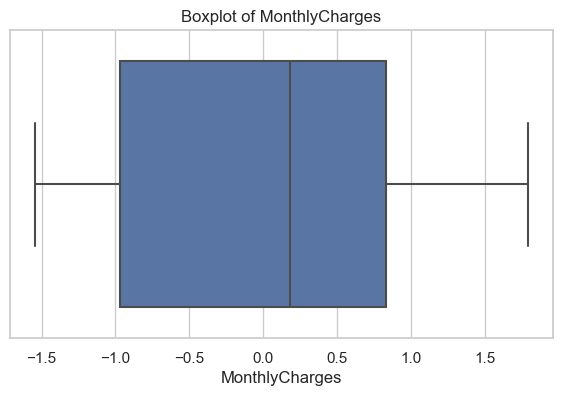

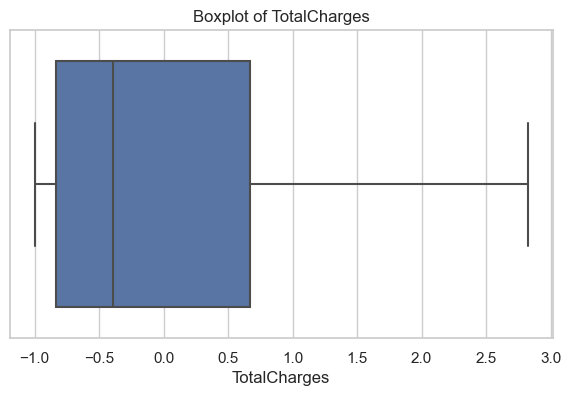

In [22]:
# Outliers detection
# 1. Select numerical variables for outlier analysis
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

# 2. Visualize outliers using boxplots
for col in num_cols:
    plt.figure(figsize=(7, 4))
    sns.boxplot(x=cleaned_df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()